In [1]:
import torch
import torch.nn.utils.prune as prune
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.nn.utils.prune as prune
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from models import ResNet18
from torchinfo import summary

In [2]:
# Load ResNet model
model = ResNet18()
# Load pretrained checkpoint
checkpoint = torch.load('Models Weights/Resnet18_structured_pruned_30_augmix_25ep.pth', map_location='cuda')
state_dict = checkpoint['net']

/tmp/ipykernel_2215227/2705538091.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('Models Weights/Resnet18_structured_pruned_30_augmix_25ep.pth',

In [3]:
# Remove 'module.' if using DataParallel
new_state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(new_state_dict)

<All keys matched successfully>

In [4]:
# Move model to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

In [5]:
# Lists to track metrics
train_losses = []
train_accs = []
test_losses = []
test_accs = []
best_epoch = 0
best_state = None

In [6]:
# Data
print('==> Preparing data..')
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=100, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified


In [7]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    use_amp = (device == "cuda")
    with torch.inference_mode():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    outputs = model(inputs)
            else:
                outputs = model(inputs)  # keep float32 on CPU

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    print(f"Accuracy: {acc:.2f}%")
    return acc

In [8]:
# Evaluate the baseline model
evaluate(model, testloader)

Accuracy: 92.15%


92.15

In [9]:
#summary(model, input_size=(128, 3, 32, 32), dtypes=[torch.float16], device=device)

In [10]:
# list of pruning amounts
pruning_amounts = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

# Unstructured pruning settings
pruning_method = prune.l1_unstructured
parameters_to_prune_types = (nn.Conv2d, nn.Linear)

Accuracy: 92.15%
Accuracy: 92.18%
Accuracy: 92.16%
Accuracy: 92.19%
Accuracy: 92.18%
Accuracy: 92.16%
Accuracy: 91.92%
Accuracy: 92.07%
Accuracy: 90.89%


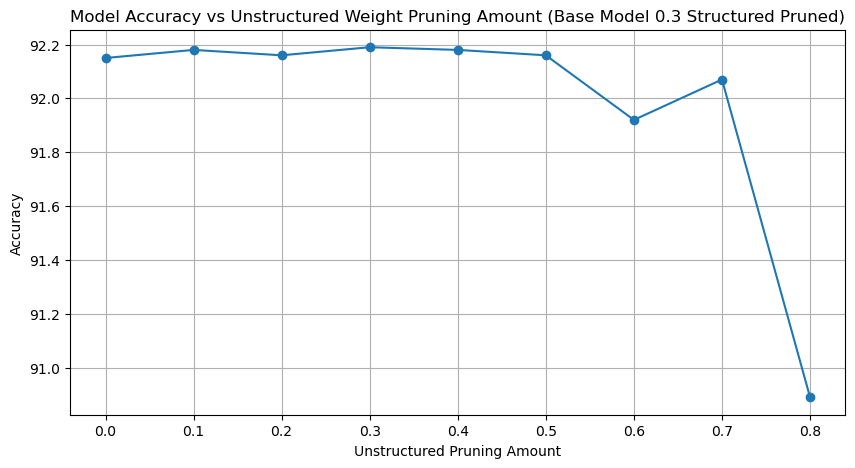

In [11]:
# Unstructured pruning from the same original model for each amount (non-cumulative)
import copy

accuracies = []

# Build a clean base model once from original checkpoint weights
base_model = ResNet18().to(device)
base_model.load_state_dict(new_state_dict)
base_model.half()

for amount in pruning_amounts:
    # Fresh copy every iteration so pruning does NOT accumulate
    model_pruned = copy.deepcopy(base_model)

    # Apply unstructured pruning layer-by-layer on weights
    for module in model_pruned.modules():
        if isinstance(module, parameters_to_prune_types):
            pruning_method(
                module,
                name='weight',
                amount=amount,
            )
            prune.remove(module, 'weight')

    acc = evaluate(model_pruned, testloader)
    accuracies.append(acc)

# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(pruning_amounts, accuracies, marker='o')
plt.xlabel('Unstructured Pruning Amount')
plt.ylabel('Accuracy')
plt.title('Model Accuracy vs Unstructured Weight Pruning Amount (Base Model 0.3 Structured Pruned)')
plt.grid(True)
plt.show()


===== Unstructured pruning amount: 0.1 =====
Accuracy: 92.18%
Pre-finetune accuracy (0.1): 92.18%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 2s364ms | Tot: 1m5s | Loss: 1.057 | Acc: 68.239% (34119/5000 391/391   
 [================================================================>]  Step: 55ms | Tot: 5s527ms | Loss: 0.447 | Acc: 90.420% (9042/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.045 | Acc: 69.031% (34515/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s528ms | Loss: 0.426 | Acc: 89.690% (8969/1000 100/100 

Epoch: 2
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.050 | Acc: 68.611% (34305/5000 391/391 91  
 [========

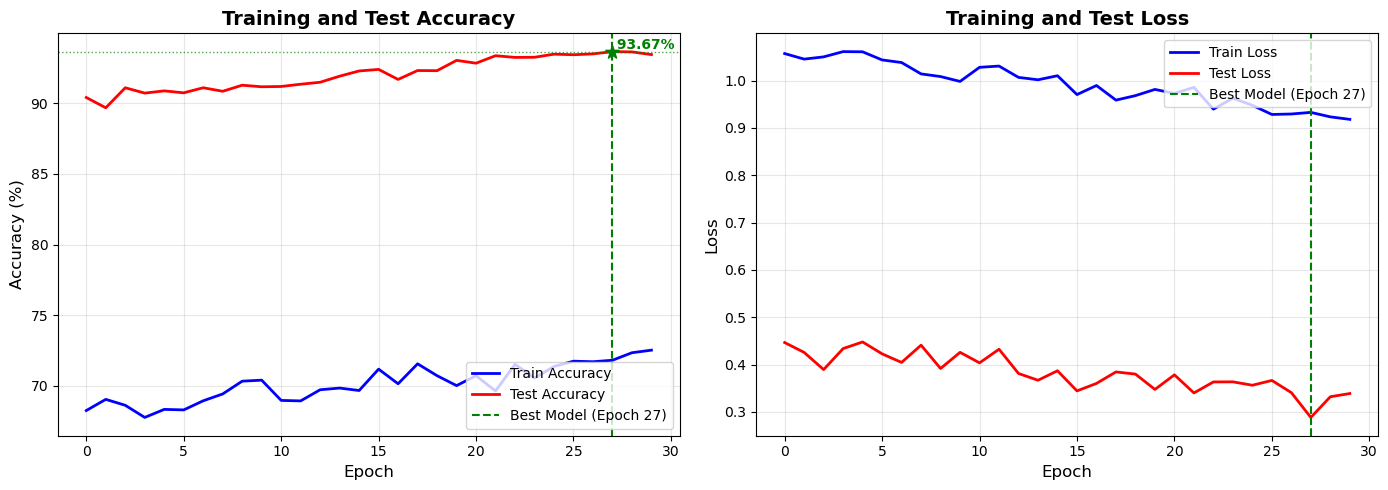

Best model achieved 93.67% accuracy at epoch 27
Best model saved at ./Models Weights/Resnet18_unstructured_pruned_10_basemodel_0.3structured_augmix_30ep.pth


===== Unstructured pruning amount: 0.3 =====
Accuracy: 92.19%
Pre-finetune accuracy (0.3): 92.19%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.045 | Acc: 68.697% (34348/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s530ms | Loss: 0.406 | Acc: 91.070% (9107/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.065 | Acc: 67.787% (33893/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s534ms | Loss: 0.442 | Acc: 89.900% (8990/1000 100/100 

Epoch: 2


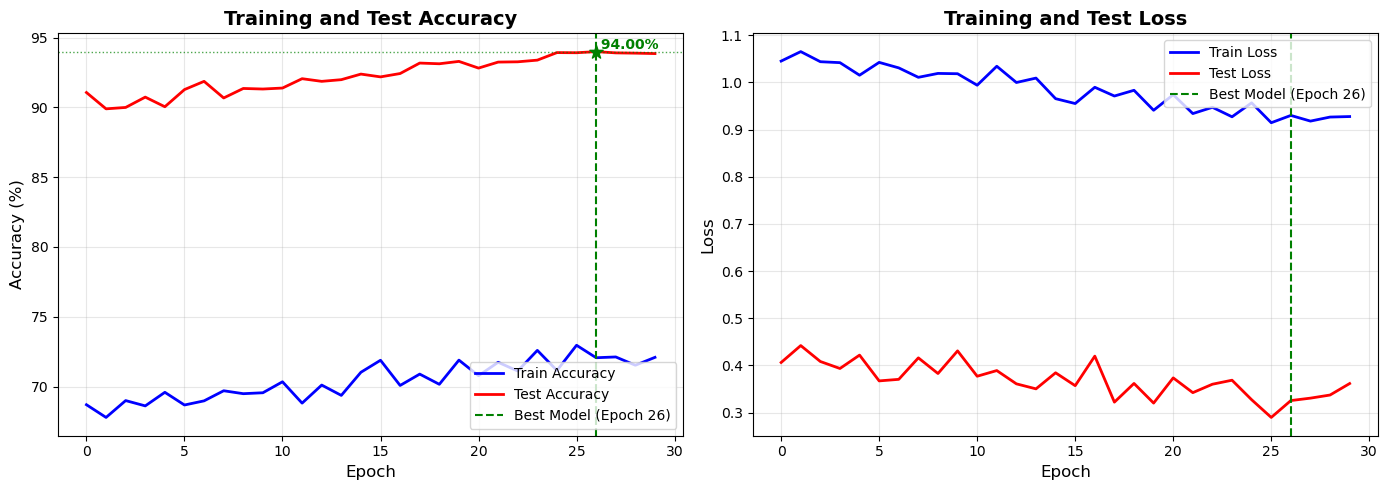

Best model achieved 94.00% accuracy at epoch 26
Best model saved at ./Models Weights/Resnet18_unstructured_pruned_30_basemodel_0.3structured_augmix_30ep.pth


===== Unstructured pruning amount: 0.5 =====
Accuracy: 92.16%
Pre-finetune accuracy (0.5): 92.16%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.030 | Acc: 69.234% (34616/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s529ms | Loss: 0.458 | Acc: 89.670% (8967/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 105ms | Tot: 1m2s | Loss: 1.069 | Acc: 67.463% (33731/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s530ms | Loss: 0.412 | Acc: 90.770% (9077/1000 100/100 
Saving..



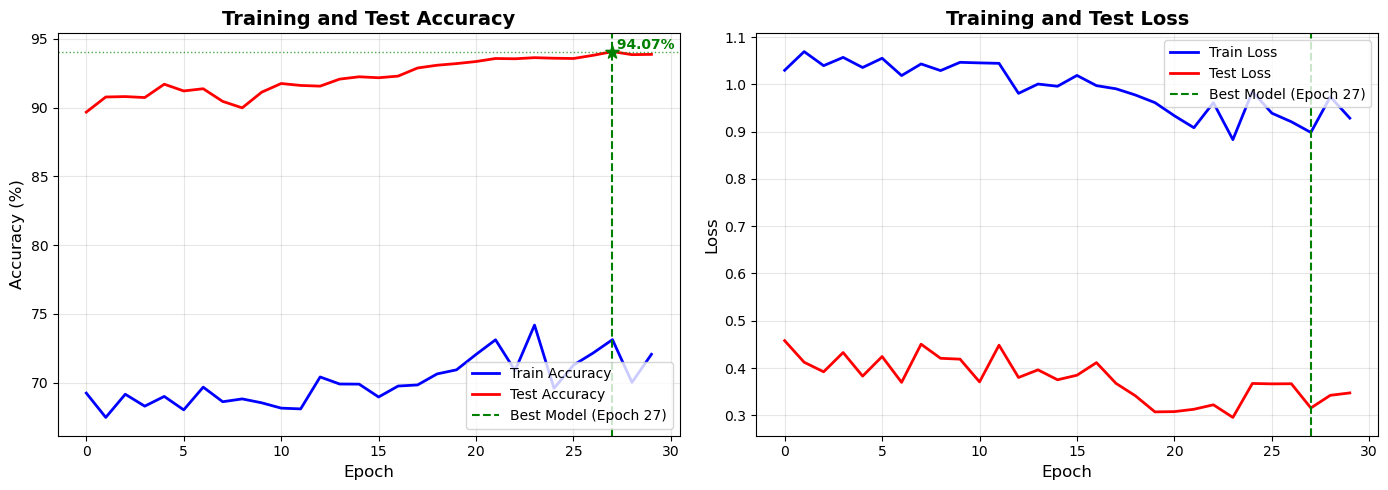

Best model achieved 94.07% accuracy at epoch 27
Best model saved at ./Models Weights/Resnet18_unstructured_pruned_50_basemodel_0.3structured_augmix_30ep.pth


===== Unstructured pruning amount: 0.7 =====
Accuracy: 92.07%
Pre-finetune accuracy (0.7): 92.07%
==> Preparing data..
Files already downloaded and verified
Files already downloaded and verified
==> Building model..

Epoch: 0
 [================================================================>]  Step: 106ms | Tot: 1m2s | Loss: 1.094 | Acc: 66.542% (33271/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s528ms | Loss: 0.442 | Acc: 90.550% (9055/1000 100/100 
Saving..

Epoch: 1
 [================================================================>]  Step: 106ms | Tot: 1m3s | Loss: 1.060 | Acc: 68.469% (34234/5000 391/391 91  
 [================================================================>]  Step: 55ms | Tot: 5s533ms | Loss: 0.427 | Acc: 90.770% (9077/1000 100/100 
Saving..



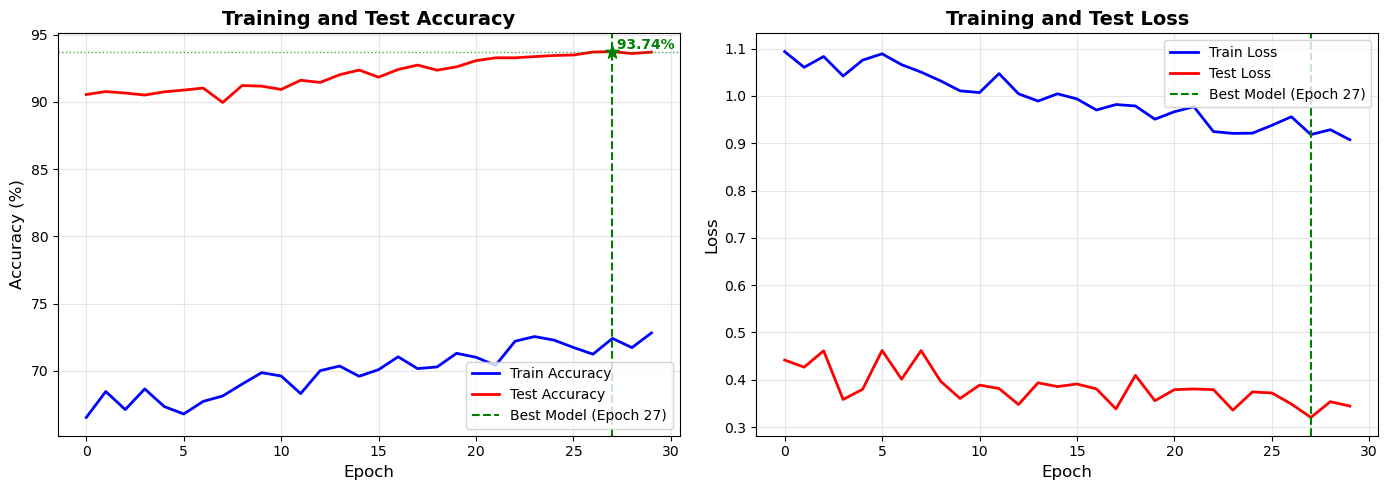

Best model achieved 93.74% accuracy at epoch 27
Best model saved at ./Models Weights/Resnet18_unstructured_pruned_70_basemodel_0.3structured_augmix_30ep.pth



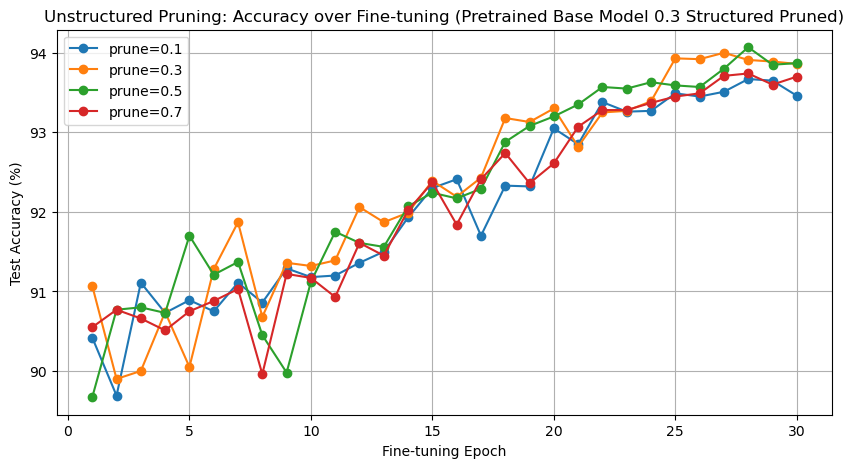

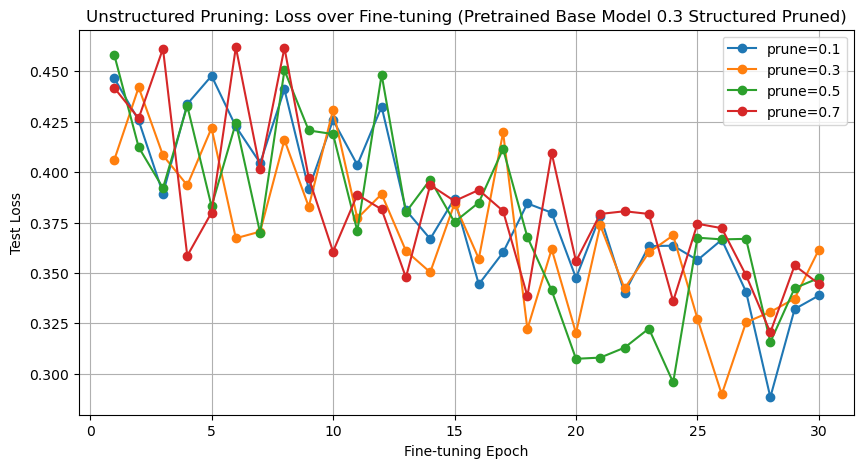

prune=0.1 | best_acc=93.67% at epoch 27 | saved=./Models Weights/Resnet18_unstructured_pruned_10_basemodel_0.3structured_augmix_30ep.pth
prune=0.3 | best_acc=94.00% at epoch 26 | saved=./Models Weights/Resnet18_unstructured_pruned_30_basemodel_0.3structured_augmix_30ep.pth
prune=0.5 | best_acc=94.07% at epoch 27 | saved=./Models Weights/Resnet18_unstructured_pruned_50_basemodel_0.3structured_augmix_30ep.pth
prune=0.7 | best_acc=93.74% at epoch 27 | saved=./Models Weights/Resnet18_unstructured_pruned_70_basemodel_0.3structured_augmix_30ep.pth


In [12]:
import copy
import importlib
import train_augmentation
import matplotlib.pyplot as plt

# Reload to pick latest changes
importlib.reload(train_augmentation)

# 4 unstructured pruning levels to compare during fine-tuning
pruning_amounts_finetune = [0.1, 0.3, 0.5, 0.7]
epochs_finetune = 30

histories = {}

for prune_amount in pruning_amounts_finetune:
    print(f"\n===== Unstructured pruning amount: {prune_amount} =====")
    model_to_train = copy.deepcopy(base_model)

    for module in model_to_train.modules():
        if isinstance(module, parameters_to_prune_types):
            pruning_method(
                module,
                name='weight',
                amount=prune_amount,
            )
            prune.remove(module, 'weight')

    pre_ft_acc = evaluate(model_to_train, testloader)
    print(f"Pre-finetune accuracy ({prune_amount}): {pre_ft_acc:.2f}%")

    results = train_augmentation.train_with_augmentation(
        model=model_to_train,
        epochs=epochs_finetune,
        resume=False,
        mixup=True,
        mixup_alpha=1.0,
        save_name=f"Resnet18_unstructured_pruned_{int(prune_amount*100)}_basemodel_0.3structured_augmix_{epochs_finetune}ep",
        lr=0.01,
    )

    histories[prune_amount] = {
        'test_accs': results['test_accs'],
        'test_losses': results['test_losses'],
        'best_acc': results['best_acc'],
        'best_epoch': results['best_epoch'],
        'save_path': results['save_path'],
    }

# Plot 1: accuracy over fine-tuning epochs for the 4 pruned models
epochs = range(1, epochs_finetune + 1)
plt.figure(figsize=(10, 5))
for amount in pruning_amounts_finetune:
    plt.plot(epochs, histories[amount]['test_accs'], marker='o', label=f'prune={amount}')
plt.xlabel('Fine-tuning Epoch')
plt.ylabel('Test Accuracy (%)')
plt.title('Unstructured Pruning: Accuracy over Fine-tuning (Pretrained Base Model 0.3 Structured Pruned)')
plt.grid(True)
plt.legend()
plt.show()

# Plot 2: loss over fine-tuning epochs for the 4 pruned models
plt.figure(figsize=(10, 5))
for amount in pruning_amounts_finetune:
    plt.plot(epochs, histories[amount]['test_losses'], marker='o', label=f'prune={amount}')
plt.xlabel('Fine-tuning Epoch')
plt.ylabel('Test Loss')
plt.title('Unstructured Pruning: Loss over Fine-tuning (Pretrained Base Model 0.3 Structured Pruned)')
plt.grid(True)
plt.legend()
plt.show()

for amount in pruning_amounts_finetune:
    h = histories[amount]
    print(
        f"prune={amount} | best_acc={h['best_acc']:.2f}% at epoch {h['best_epoch']} | saved={h['save_path']}"
    )